# Base CNN Training and Video Prediction

This notebook is strictly for a custom base CNN (no transfer learning).

Workflow:
1. Train base CNN on your image classes.
2. Evaluate the base CNN.
3. Run prediction on the same input video.
4. Save an output video with predicted class and confidence per frame.

You can then compare this output with your pretrained YOLO output.

In [1]:
# If needed, uncomment to install dependencies
%pip install tensorflow opencv-python matplotlib roboflow pyyaml

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached idna-3.7-py3-none-any.whl.metadata (9.9 kB)
  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.6 MB ? eta -:--:--
   ---------------------------------------- 1.0/350.6 MB 3.6 MB/s eta 0:0

In [2]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import yaml
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from trackers.tracker import Tracker
from utils.video_utils import read_video, save_video

print('TensorFlow version:', tf.__version__)
print('GPU count:', len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.21.0
GPU count: 0


In [3]:
# Configuration
# DATA_DIR must be a classification folder with class subfolders.
DATA_DIR = Path('../training/classification_dataset')  # Change this

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15

INPUT_VIDEO_DIR = Path('input_videos')
video_candidates = sorted(INPUT_VIDEO_DIR.glob('*.mp4'))
VIDEO_INPUT = video_candidates[0] if video_candidates else INPUT_VIDEO_DIR / 'input.mp4'
OUTPUT_DIR = Path('output_videos')
OUTPUT_VIDEO = OUTPUT_DIR / 'base_model_prediction.mp4'
MODEL_PATH = Path('base_cnn_model.keras')
DETECTOR_MODEL_PATH = Path('models/best.pt')
TRACK_STUB_PATH = Path('output_videos/base_model_tracks_stub.pkl')

print('DATA_DIR exists:', DATA_DIR.exists())
print('VIDEO_INPUT:', VIDEO_INPUT)
print('VIDEO_INPUT exists:', VIDEO_INPUT.exists())
print('DETECTOR_MODEL_PATH exists:', DETECTOR_MODEL_PATH.exists())

DATA_DIR exists: True
VIDEO_INPUT: input_videos\08fd33_4.mp4
VIDEO_INPUT exists: True
DETECTOR_MODEL_PATH exists: True


In [4]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = os.getenv('ROBOFLOW_API_KEY')
if ROBOFLOW_API_KEY:
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace('roboflow-jvuqo').project('football-players-detection-3zvbc')
    version = project.version(1)
    dataset = version.download('yolov5')

    YOLO_DATASET_DIR = Path(dataset.location)
    print('Downloaded YOLO dataset to:', YOLO_DATASET_DIR.resolve())
else:
    print('ROBOFLOW_API_KEY is not set, skipping download and using local YOLO dataset path instead.')

ROBOFLOW_API_KEY is not set, skipping download and using local YOLO dataset path instead.


In [5]:
# If you did not run Roboflow download above, set YOLO_DATASET_DIR manually.
# Example: YOLO_DATASET_DIR = Path('../training/football-players-detection-1/football-players-detection-1')

if 'YOLO_DATASET_DIR' not in globals():
    YOLO_DATASET_DIR = Path('../training/football-players-detection-1/football-players-detection-1')

CLASSIFICATION_DIR = Path('../training/classification_dataset')
CLASSIFICATION_DIR.mkdir(parents=True, exist_ok=True)

# Try to read class names from data.yaml; fallback to numeric class names.
class_name_map = {}
data_yaml = YOLO_DATASET_DIR / 'data.yaml'
if data_yaml.exists():
    with open(data_yaml, 'r', encoding='utf-8') as f:
        data_cfg = yaml.safe_load(f)
    names = data_cfg.get('names', [])
    if isinstance(names, dict):
        class_name_map = {int(k): str(v) for k, v in names.items()}
    elif isinstance(names, list):
        class_name_map = {i: str(v) for i, v in enumerate(names)}

valid_exts = ['.jpg', '.jpeg', '.png', '.bmp']
saved_count = 0
split_counts = {}

for split in ['train', 'valid', 'test']:
    images_dir = YOLO_DATASET_DIR / split / 'images'
    labels_dir = YOLO_DATASET_DIR / split / 'labels'
    if not images_dir.exists() or not labels_dir.exists():
        continue

    split_saved = 0
    for label_file in labels_dir.glob('*.txt'):
        stem = label_file.stem
        image_path = None
        for ext in valid_exts:
            candidate = images_dir / f'{stem}{ext}'
            if candidate.exists():
                image_path = candidate
                break
        if image_path is None:
            continue

        image = cv2.imread(str(image_path))
        if image is None:
            continue

        h, w = image.shape[:2]
        with open(label_file, 'r', encoding='utf-8') as f:
            rows = [line.strip() for line in f if line.strip()]

        for i, row in enumerate(rows):
            parts = row.split()
            if len(parts) != 5:
                continue

            cls_id = int(float(parts[0]))
            x_center = float(parts[1]) * w
            y_center = float(parts[2]) * h
            bw = float(parts[3]) * w
            bh = float(parts[4]) * h

            x1 = max(0, int(x_center - bw / 2))
            y1 = max(0, int(y_center - bh / 2))
            x2 = min(w, int(x_center + bw / 2))
            y2 = min(h, int(y_center + bh / 2))

            if x2 <= x1 or y2 <= y1:
                continue

            crop = image[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            class_name = class_name_map.get(cls_id, f'class_{cls_id}')
            class_dir = CLASSIFICATION_DIR / class_name
            class_dir.mkdir(parents=True, exist_ok=True)

            out_name = f'{split}_{stem}_{i}.jpg'
            out_path = class_dir / out_name
            cv2.imwrite(str(out_path), crop)

            saved_count += 1
            split_saved += 1

    split_counts[split] = split_saved

DATA_DIR = CLASSIFICATION_DIR
print('Classification dataset:', DATA_DIR.resolve())
print('Total crops saved:', saved_count)
print('Saved per split:', split_counts)

Classification dataset: C:\Users\fajayi\COMP-3704-Neural_Networks_and_Deep_Learning_Notebook\Real-Time-Football-Player-Tactics-Tracking-Using-Deep-Learning\training\classification_dataset
Total crops saved: 15797
Saved per split: {'train': 14583, 'valid': 905, 'test': 309}


## Convert YOLO Detection Dataset To Classification Crops

This creates class folders from YOLO bounding boxes so the base CNN can train with image_dataset_from_directory.

## Optional: Download Dataset From Roboflow

Use this if you want to pull the same dataset directly from Roboflow in YOLO format, then convert to classification crops for the base CNN.

Security note: do not hardcode your API key in the notebook. Use an environment variable named ROBOFLOW_API_KEY.

## Expected Image Dataset Layout

Use a classification structure:

- dataset_root/class_0/image_001.jpg
- dataset_root/class_1/image_002.jpg
- dataset_root/class_2/image_003.jpg

If your data is currently only in YOLO detection format, first create class folders for your base CNN task.

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

print('Classes:', class_names)
print('Number of classes:', num_classes)

Found 15797 files belonging to 4 classes.
Using 12638 files for training.
Found 15797 files belonging to 4 classes.
Using 3159 files for validation.
Classes: ['class_0', 'class_1', 'class_2', 'class_3']
Number of classes: 4


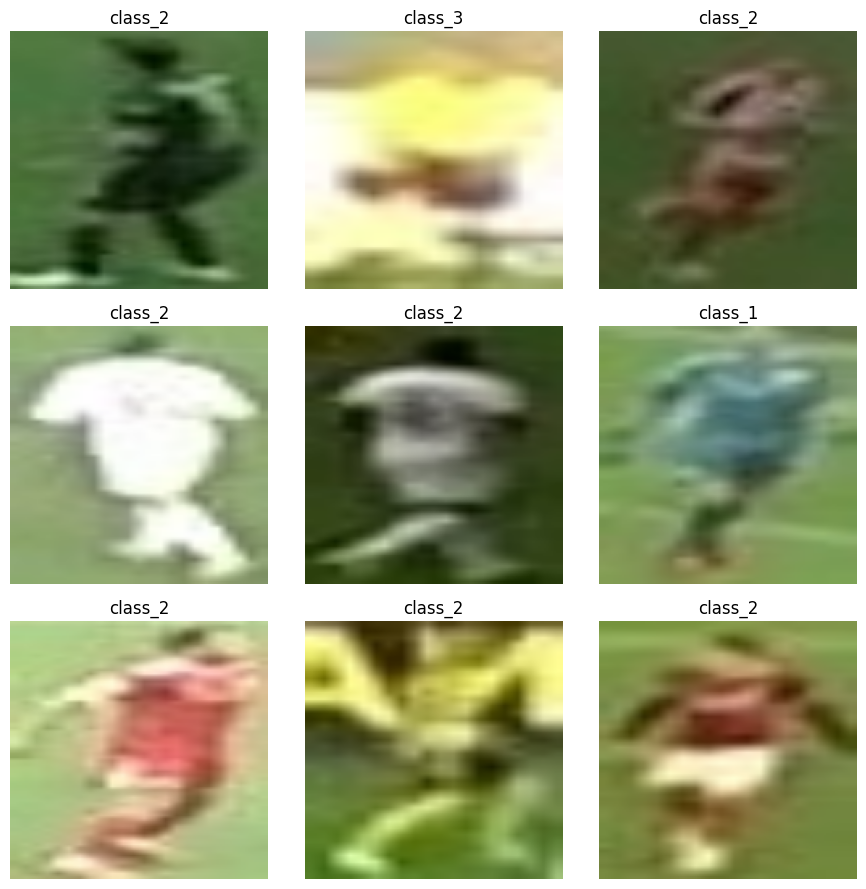

In [7]:
plt.figure(figsize=(9, 9))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.tight_layout()
plt.show()

In [8]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name='augmentation')

def build_base_cnn(input_shape=(160, 160, 3), num_classes=2):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.35),
        layers.Dense(num_classes, activation='softmax')
    ], name='base_cnn')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

base_model = build_base_cnn(input_shape=IMG_SIZE + (3,), num_classes=num_classes)
base_model.summary()

Model: "base_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,492 (25.36 MB)

 Trainable params: 6,647,492 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
]

history = base_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 105s 262ms/step - accuracy: 0.8702 - loss: 0.4075 - val_accuracy: 0.9114 - val_loss: 0.2386
Epoch 2/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 109s 277ms/step - accuracy: 0.9183 - loss: 0.2430 - val_accuracy: 0.9395 - val_loss: 0.1817
Epoch 3/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 113s 286ms/step - accuracy: 0.9349 - loss: 0.1911 - val_accuracy: 0.9449 - val_loss: 0.1573
Epoch 4/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 113s 287ms/step - accuracy: 0.9456 - loss: 0.1614 - val_accuracy: 0.9528 - val_loss: 0.1414
Epoch 5/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 113s 287ms/step - accuracy: 0.9490 - loss: 0.1527 - val_accuracy: 0.9418 - val_loss: 0.1616
Epoch 6/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 113s 286ms/step - accuracy: 0.9528 - loss: 0.1392 - val_accuracy: 0.9541 - val_loss: 0.1292
Epoch 7/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 114s 288ms/step - accuracy: 0.9563 - loss: 0.1286 - val_accuracy: 0.9699 - val_loss: 0.0806
Epoch 8/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 113s 286ms/step - accuracy: 0.9624 -

Base CNN validation loss: 0.0724
Base CNN validation accuracy: 0.9731


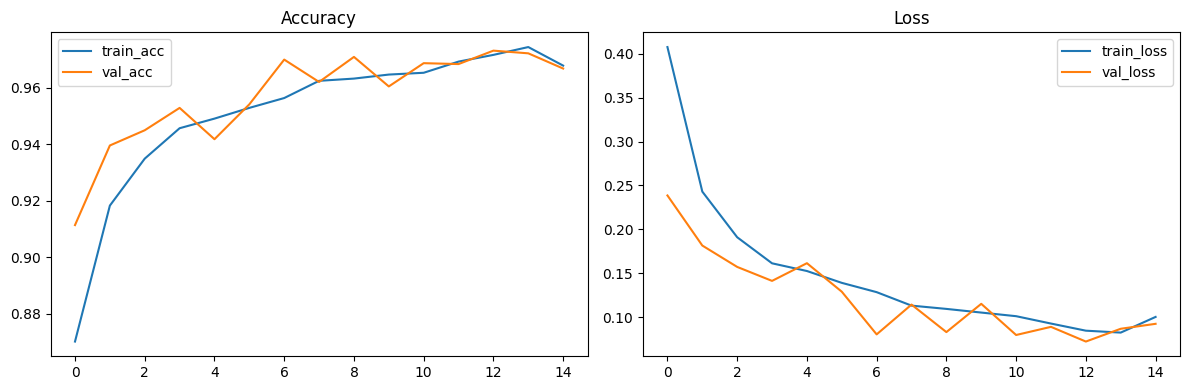

In [10]:
val_loss, val_acc = base_model.evaluate(val_ds, verbose=0)
print(f'Base CNN validation loss: {val_loss:.4f}')
print(f'Base CNN validation accuracy: {val_acc:.4f}')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
base_model.save(MODEL_PATH)
print('Saved model to:', MODEL_PATH.resolve())

Saved model to: C:\Users\fajayi\COMP-3704-Neural_Networks_and_Deep_Learning_Notebook\Real-Time-Football-Player-Tactics-Tracking-Using-Deep-Learning\football_analysis_final\base_cnn_model.keras


In [12]:
# Reload model before video inference (optional)
inference_model = keras.models.load_model(MODEL_PATH)
tracker = Tracker(str(DETECTOR_MODEL_PATH))

def classify_crop(frame_bgr, bbox):
    x1, y1, x2, y2 = [int(v) for v in bbox]
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = max(x1 + 1, x2)
    y2 = max(y1 + 1, y2)

    crop = frame_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        return 'unknown', 0.0

    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(crop_rgb, IMG_SIZE)
    x = resized.astype(np.float32) / 255.0
    x = np.expand_dims(x, axis=0)

    probs = inference_model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    confidence = float(probs[pred_idx])
    return pred_class, confidence

def draw_cnn_label(frame, bbox, track_id, class_name, confidence, color):
    x1, y1, x2, y2 = [int(v) for v in bbox]
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
    label = f'ID {track_id} | {class_name} {confidence:.2f}'
    label_y = max(25, y1 - 10)
    cv2.putText(frame, label, (x1, label_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)
    return frame

In [13]:
# Predict on video and save YOLO-like annotated output video
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

video_frames = read_video(str(VIDEO_INPUT))
if not video_frames:
    raise FileNotFoundError(f'Could not open video: {VIDEO_INPUT}')

tracks = tracker.get_object_tracks(
    video_frames,
    read_from_stub=True,
    stub_path=str(TRACK_STUB_PATH)
 )
if not tracks or len(tracks.get('players', [])) == 0:
    tracks = tracker.get_object_tracks(
        video_frames,
        read_from_stub=False,
        stub_path=str(TRACK_STUB_PATH)
    )

annotated_frames = []
for frame_num, frame in enumerate(video_frames):
    frame = frame.copy()
    player_dict = tracks['players'][frame_num] if frame_num < len(tracks['players']) else {}
    referee_dict = tracks['referees'][frame_num] if frame_num < len(tracks['referees']) else {}
    ball_dict = tracks['ball'][frame_num] if frame_num < len(tracks['ball']) else {}

    for track_id, player in player_dict.items():
        bbox = player['bbox']
        pred_class, confidence = classify_crop(frame, bbox)
        color = (0, 255, 0) if confidence >= 0.5 else (0, 165, 255)
        frame = draw_cnn_label(frame, bbox, track_id, pred_class, confidence, color)
        frame = tracker.draw_ellipse(frame, bbox, color, track_id)

    for _, referee in referee_dict.items():
        frame = tracker.draw_ellipse(frame, referee['bbox'], (0, 255, 255))

    for _, ball in ball_dict.items():
        frame = tracker.draw_traingle(frame, ball['bbox'], (0, 255, 0))

    annotated_frames.append(frame)

save_video(annotated_frames, str(OUTPUT_VIDEO))
print('Frames processed:', len(annotated_frames))
print('Saved video:', OUTPUT_VIDEO.resolve())

Read 100 frames
Read 200 frames
Read 300 frames
Read 400 frames
Read 500 frames
Read 600 frames
Read 700 frames
Read 800 frames
Read 900 frames
EOF reached at frame 900
Total frames read: 900
[YOLO] Processing frames 1/900
[YOLO] Processing frames 2/900
[YOLO] Processing frames 3/900
[YOLO] Processing frames 4/900
[YOLO] Processing frames 5/900
[YOLO] Processing frames 6/900
[YOLO] Processing frames 7/900
[YOLO] Processing frames 8/900
[YOLO] Processing frames 9/900
[YOLO] Processing frames 10/900
[YOLO] Processing frames 11/900
[YOLO] Processing frames 12/900
[YOLO] Processing frames 13/900
[YOLO] Processing frames 14/900
[YOLO] Processing frames 15/900
[YOLO] Processing frames 16/900
[YOLO] Processing frames 17/900
[YOLO] Processing frames 18/900
[YOLO] Processing frames 19/900
[YOLO] Processing frames 20/900
[YOLO] Processing frames 21/900
[YOLO] Processing frames 22/900
[YOLO] Processing frames 23/900
[YOLO] Processing frames 24/900
[YOLO] Processing frames 25/900
[YOLO] Processing

## Compare With YOLO

Now compare:
- this notebook output video: `output_videos/base_model_prediction.mp4`
- your YOLO output video on the same input clip

For a fair comparison, use the exact same source video and similar clip duration.